In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Simple Plotly setup (minimal)
import plotly.io as pio
pio.renderers.default = "notebook"  # In case of error, install nbformat
%pip install -q "nbformat>=4.2.0"
import nbformat  # if ImportError: run `pip install nbformat`



Note: you may need to restart the kernel to use updated packages.


In [3]:
#importing all datasets
february = pd.read_csv('original_datasets/CRMLSSold202502_filled.csv')
march = pd.read_csv('original_datasets/CRMLSSold202503_filled.csv')
april = pd.read_csv('original_datasets/CRMLSSold202504_filled.csv')
may = pd.read_csv('original_datasets/CRMLSSold202505_filled.csv')
june = pd.read_csv('original_datasets/CRMLSSold202506_filled.csv')
july = pd.read_csv('original_datasets/CRMLSSold202507_filled.csv')
august = pd.read_csv('original_datasets/CRMLSSold202508_filled-2.csv')
september = pd.read_csv('original_datasets/CRMLSSold202509.csv')

C:\Users\jueeh\AppData\Local\Temp\ipykernel_34156\3343253333.py:6: DtypeWarning:

Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.



In [4]:
combined_dataset = pd.concat([february, march, april, may, june, july, august, september], ignore_index=True)
combined_dataset

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
0,RanchoSoutheast,RanchoSoutheast,NaN,True,NaN,NaN,NaN,60000.0,526199946,cmark1018@yahoo.com,...,NaN,False,NaN,NaN,92307,0.0,28000.0,NaN,False,False
1,InlandValleys,InlandValleys,NaN,False,NaN,NaN,NaN,550000.0,525585060,mozcorona@aol.com,...,NaN,False,NaN,NaN,92553,0.0,39640.0,NaN,False,False
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,880000.0,497696903,lenskab@gmail.com,...,NaN,False,2.0,NaN,91942,NaN,NaN,NaN,False,False
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,875000.0,497696407,lenskab@gmail.com,...,NaN,False,2.0,NaN,91942,NaN,NaN,NaN,False,False
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,849000.0,486616176,lenskab@gmail.com,...,NaN,False,2.0,NaN,91942,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178502,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,24800.0,1018638495,javi4uhome@gmail.com,...,NaN,False,NaN,NaN,92230,0.0,5663.0,NaN,NaN,NaN
178503,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,249900.0,1016742369,jerryavila@allnationsontario.com,...,NaN,False,NaN,NaN,92365,0.0,4356000.0,NaN,NaN,NaN
178504,SierraNorthValley,SierraNorthValley,NaN,True,NaN,NaN,NaN,115000.0,1014482709,blake@virtualhomesales.net,...,NaN,False,NaN,NaN,95916,0.0,418176.0,NaN,NaN,NaN
178505,Oroville,Oroville,NaN,True,NaN,NaN,NaN,117000.0,1014210894,steffan@steffanblaser.com,...,NaN,False,NaN,NaN,95916,0.0,152460.0,NaN,NaN,NaN


In [5]:
print(combined_dataset.shape)
combined_dataset.info()
combined_dataset.describe(include='all')
combined_dataset.isna().mean().sort_values(ascending=False).head(20)

(178507, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178507 entries, 0 to 178506
Data columns (total 80 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 178431 non-null  object 
 1   ListAgentAOR                  178431 non-null  object 
 2   Flooring                      105072 non-null  object 
 3   ViewYN                        160563 non-null  object 
 4   WaterfrontYN                  98 non-null      object 
 5   BasementYN                    2915 non-null    object 
 6   PoolPrivateYN                 158865 non-null  object 
 7   OriginalListPrice             177943 non-null  float64
 8   ListingKey                    178507 non-null  int64  
 9   ListAgentEmail                177841 non-null  object 
 10  CloseDate                     178507 non-null  object 
 11  ClosePrice                    178505 non-null  float64
 12  ListAgentFirstName            1

MiddleOrJuniorSchoolDistrict    1.000000
CoveredSpaces                   1.000000
AboveGradeFinishedArea          1.000000
ElementarySchoolDistrict        1.000000
FireplacesTotal                 1.000000
TaxYear                         0.999457
WaterfrontYN                    0.999451
BusinessType                    0.997625
TaxAnnualAmount                 0.996667
BelowGradeFinishedArea          0.995227
BasementYN                      0.983670
BuilderName                     0.961368
LotSizeDimensions               0.946349
CoBuyerAgentFirstName           0.918138
ElementarySchool                0.891130
MiddleOrJuniorSchool            0.890626
BuildingAreaTotal               0.868621
HighSchool                      0.857311
CoListAgentFirstName            0.789470
CoListAgentLastName             0.789050
dtype: float64

In [6]:
#drop columns with >75% missing values, as well as columns with zero variance
threshold = 0.75
cols_to_drop = combined_dataset.columns[combined_dataset.isna().mean() > threshold].tolist()
combined_dataset = combined_dataset.drop(columns=cols_to_drop)

In [7]:
zero_variance_cols = combined_dataset.columns[combined_dataset.nunique() <= 1].tolist()
combined_dataset = combined_dataset[(combined_dataset['StateOrProvince'] == 'CA')&(combined_dataset['PropertyType'] == 'Residential') & (combined_dataset['PropertySubType'] == 'SingleFamilyResidence')]
zero_variance_cols = combined_dataset.columns[combined_dataset.nunique() <= 1].tolist()
combined_dataset = combined_dataset.drop(columns=zero_variance_cols)

more_columns_to_drop = ['ListingKey', 'ListingKeyNumeric', 'ListingId', 'UnparsedAddress', 'ListPrice', 'OriginalListPrice', 'DaysOnMarket', 'AssociationFee', 'AssociationFeeFrequency', 'HighSchoolDistrict', 'BuyerAgentAOR', 'ListAgentAOR', 'BuyerOfficeAOR', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId', 'ListOfficeName', 'BuyerOfficeName', 'SubdivisionName', 'Levels']
combined_dataset = combined_dataset.drop(columns=more_columns_to_drop)

In [8]:
#visualize missing data
!pip install missingno
import missingno as msno
#(combined_dataset.isna().mean() * 100).sort_values(ascending=False)

<Axes: >

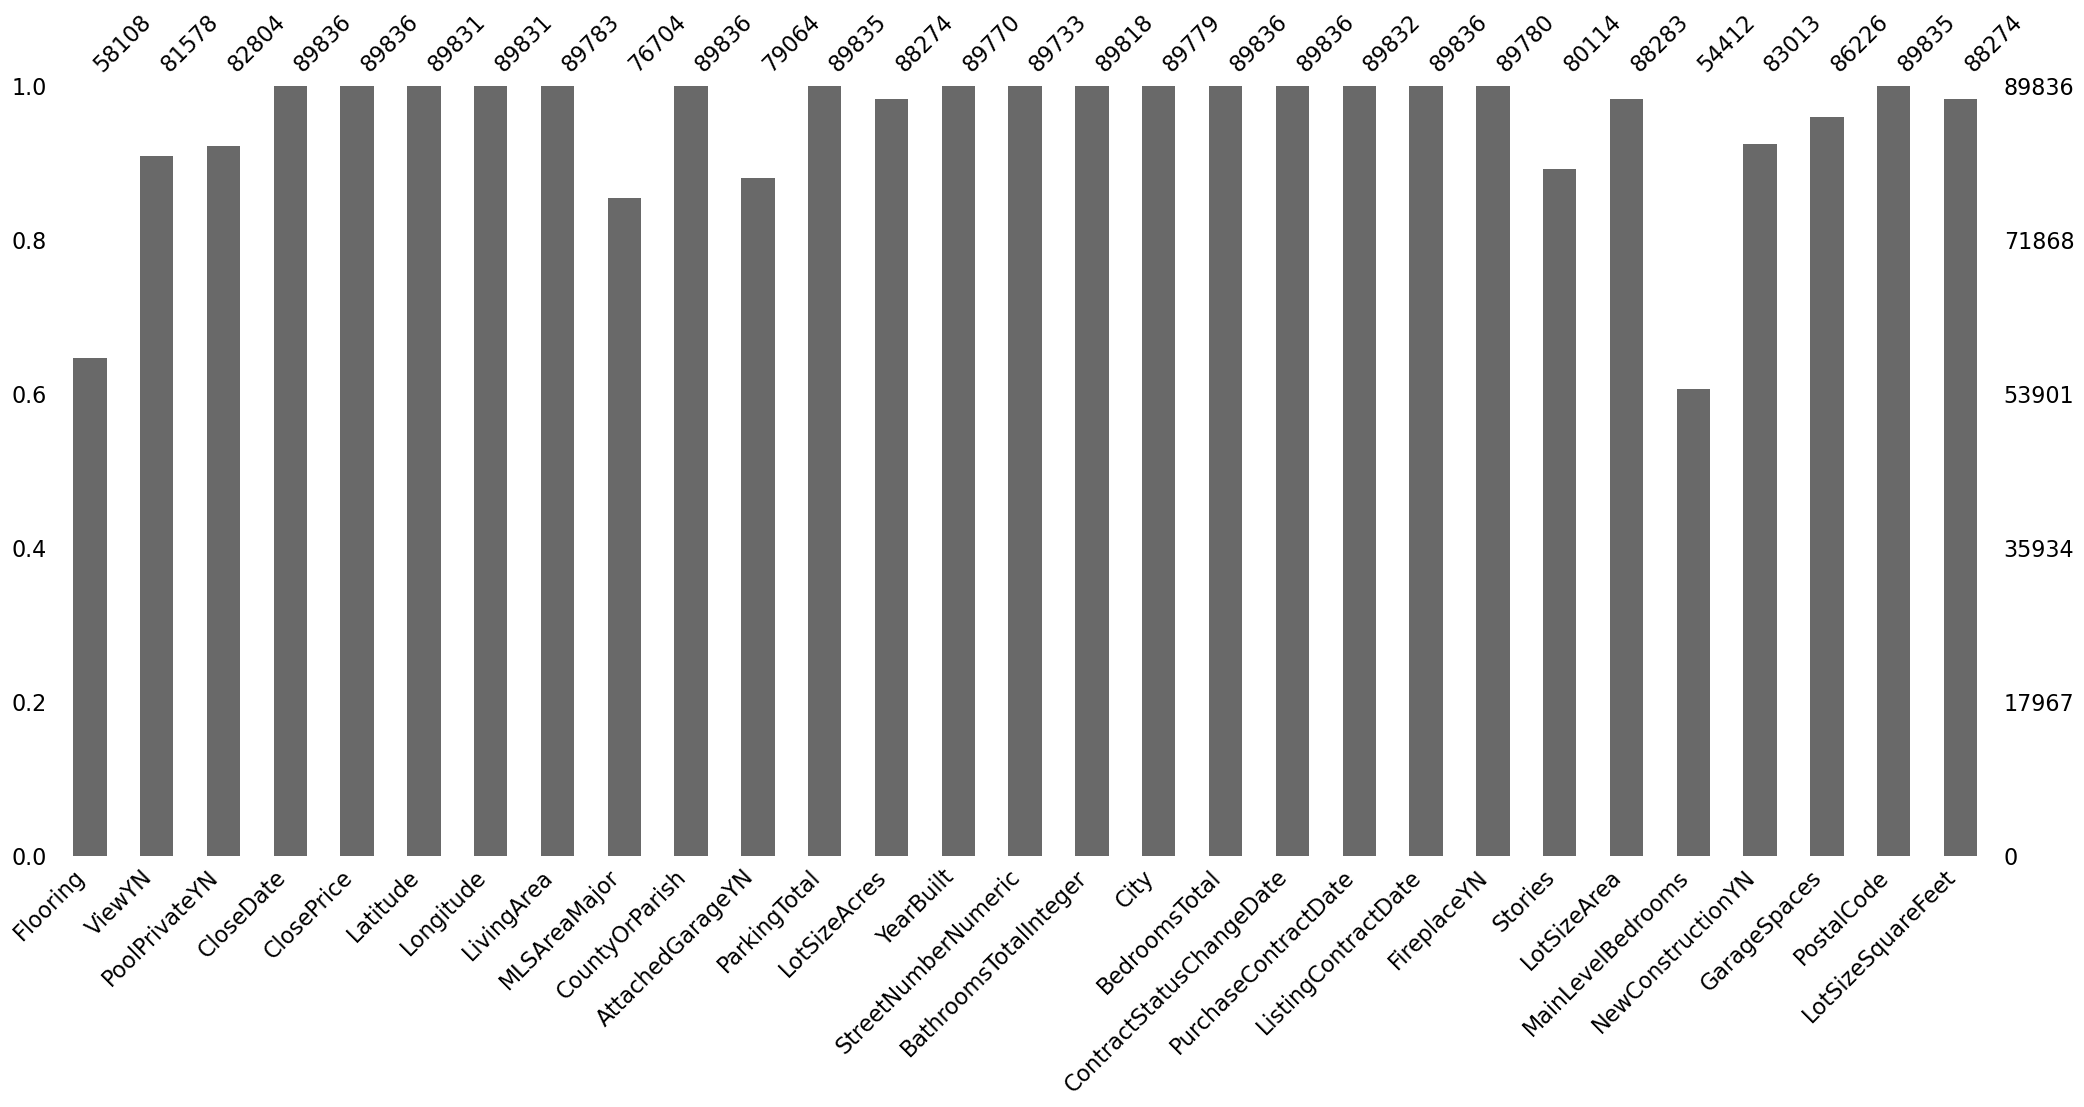

In [9]:
msno.bar(combined_dataset)

In [10]:
combined_dataset = combined_dataset.drop(columns = ['Flooring', 'MLSAreaMajor'])#lots of NaNs, also very sparse info

<Axes: >

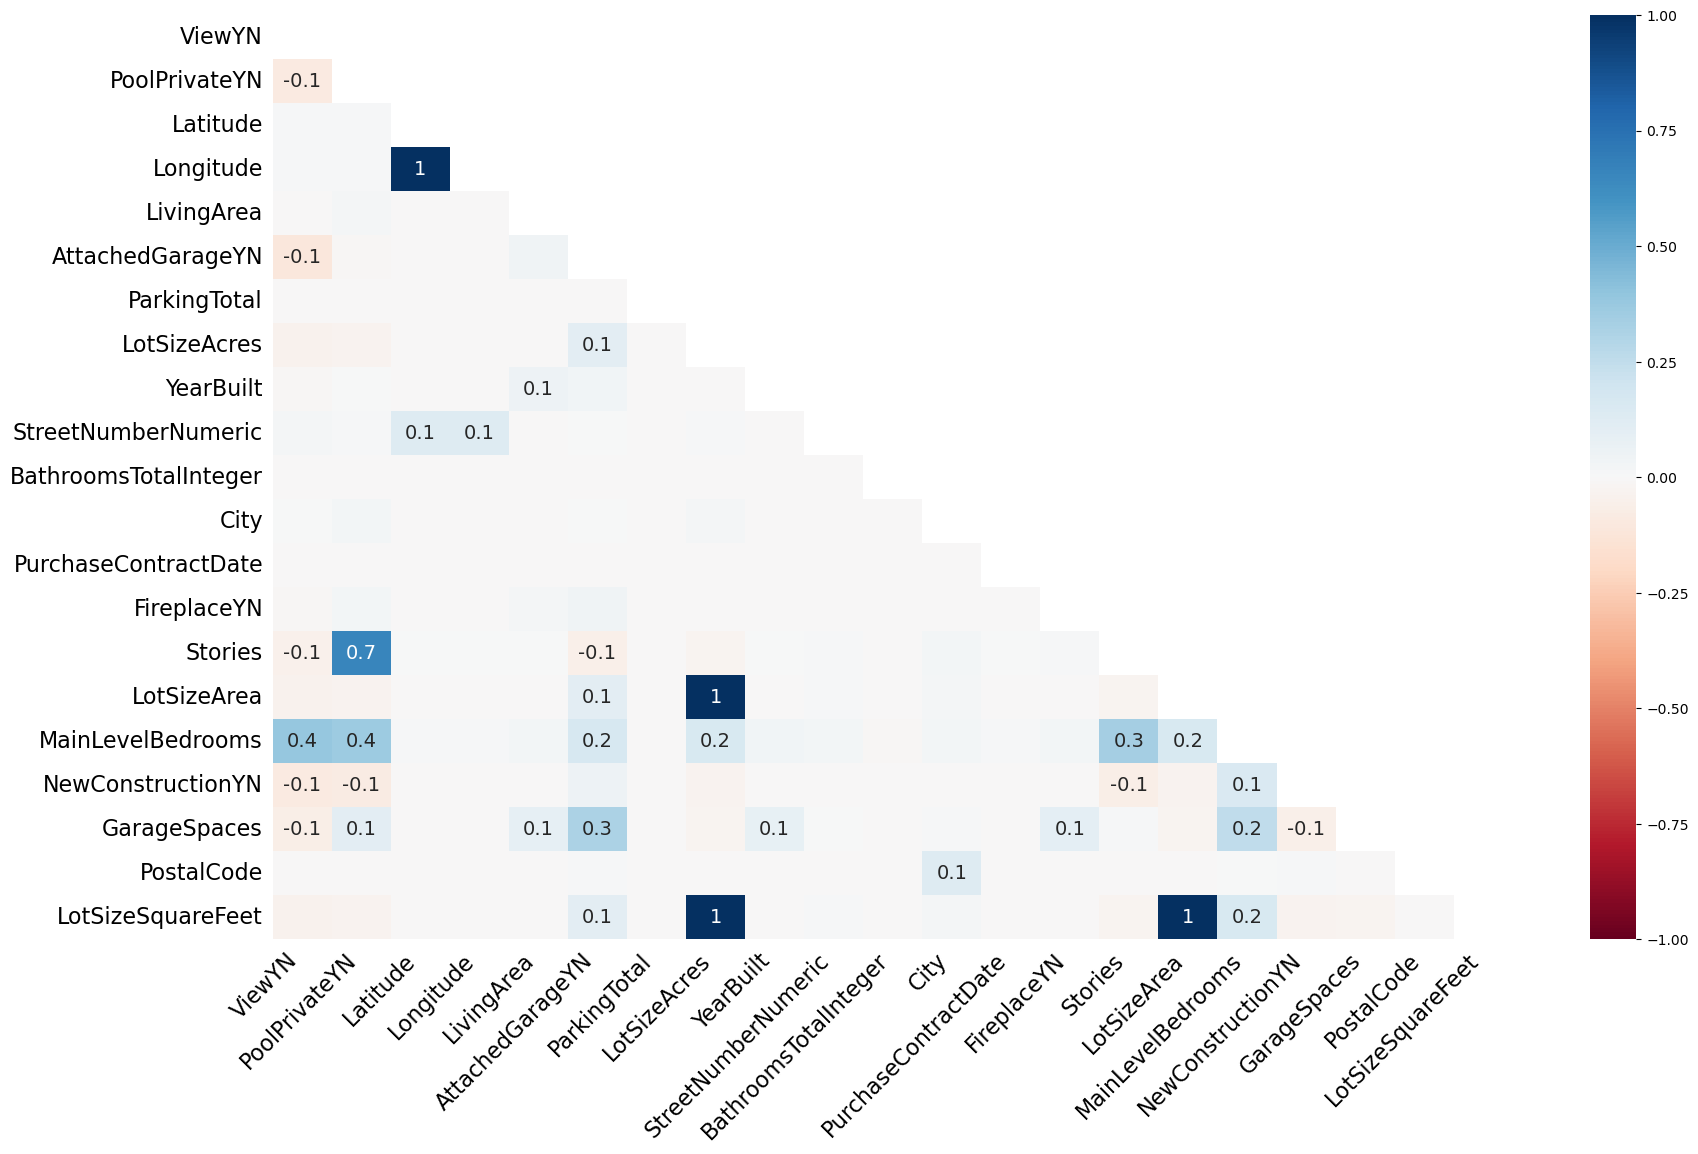

In [11]:
msno.heatmap(combined_dataset) 
#notes: if latitute is missing, longitude is missing too. Stories and PoolPrivateYN also has a strong correlation. Otherwise, not strong correlations between missingness of different columns.

In [12]:
#distribution visualization
#need to trim top and bottom 0.5% of outliers 
fig = px.histogram(combined_dataset, x='ClosePrice', nbins=30, title='Distribution of Close Price')
fig

In [13]:
close_price_bottom = combined_dataset['ClosePrice'].quantile(0.005)
close_price_top = combined_dataset['ClosePrice'].quantile(0.995)
combined_dataset = combined_dataset[(combined_dataset['ClosePrice'] >= close_price_bottom) & (combined_dataset['ClosePrice'] <= close_price_top)]
fig_2 = px.histogram(combined_dataset, x='ClosePrice', nbins=30, title='Distribution of Close Price (Trimmed)')
fig_2

In [14]:
combined_dataset['ClosePrice'].describe() #minimum is 190k, median is 900k, maximum is 8.5M

#correlations- need to do data conversions first
combined_dataset['StreetNumberNumeric'] #street number numeric won't give us any information about close price- drop it
combined_dataset = combined_dataset.drop(columns=['StreetNumberNumeric'])

In [15]:
boolean_columns = ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']
combined_dataset[boolean_columns].isna().sum()
for col in boolean_columns:
    print(combined_dataset[col].value_counts(dropna=False))


#explore why these columns have missing values- first need to do Date time conversions

ViewYN
True     49271
False    31443
NaN       8251
Name: count, dtype: int64
PoolPrivateYN
False    68135
True     13950
NaN       6880
Name: count, dtype: int64
AttachedGarageYN
True     65648
False    12893
NaN      10424
Name: count, dtype: int64
FireplaceYN
True     64701
False    24213
NaN         51
Name: count, dtype: int64
NewConstructionYN
False    79077
NaN       6802
True      3086
Name: count, dtype: int64


In [16]:
date_columns = ['PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate', 'CloseDate']
combined_dataset[date_columns] = combined_dataset[date_columns].apply(pd.to_datetime, errors='coerce')
combined_dataset[date_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 88965 entries, 2 to 178499
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   PurchaseContractDate      88961 non-null  datetime64[ns]
 1   ListingContractDate       88965 non-null  datetime64[ns]
 2   ContractStatusChangeDate  88965 non-null  datetime64[ns]
 3   CloseDate                 88965 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 3.4 MB


In [17]:
#Features of the house itself
print(combined_dataset[['LivingArea', 'ParkingTotal', 'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'MainLevelBedrooms', 'GarageSpaces', 'ClosePrice']].corr()['ClosePrice'].sort_values(ascending=False))
core_house_features = ['LivingArea', 'ParkingTotal', 'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'MainLevelBedrooms', 'GarageSpaces']

#why are there so many mainlevelbedrooms missing?

combined_dataset[['MainLevelBedrooms', 'BedroomsTotal', 'Stories']] #i feel like BedroomsTotal has more influence on ClosePrice
combined_dataset['Stories'] = combined_dataset['Stories'].fillna(1)


ClosePrice               1.000000
LivingArea               0.601810
BathroomsTotalInteger    0.551401
BedroomsTotal            0.342692
Stories                  0.236247
GarageSpaces             0.059809
ParkingTotal             0.002635
MainLevelBedrooms       -0.084252
Name: ClosePrice, dtype: float64


In [18]:
for feature in core_house_features:
    print(feature, combined_dataset[feature].isna().sum())

combined_dataset.loc[combined_dataset['GarageSpaces'].isna(), 'GarageSpaces'] = combined_dataset['ParkingTotal']

LivingArea 40
ParkingTotal 1
BathroomsTotalInteger 18
BedroomsTotal 0
Stories 0
MainLevelBedrooms 35077
GarageSpaces 3492


EDA Space

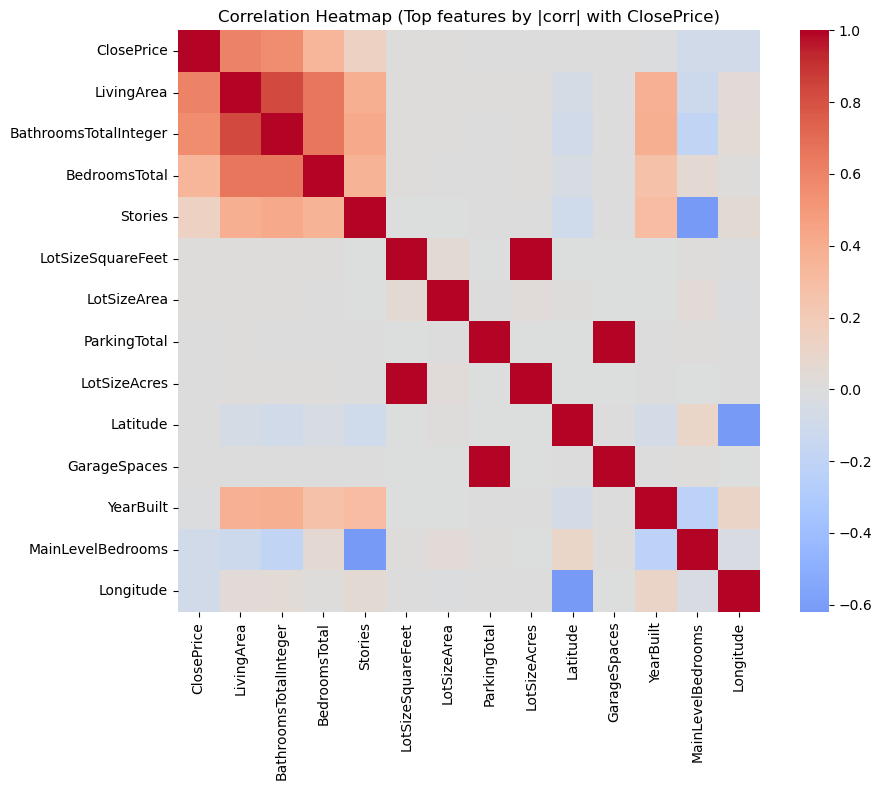

ClosePrice               1.000000
LivingArea               0.601810
BathroomsTotalInteger    0.551401
BedroomsTotal            0.342692
Stories                  0.139808
LotSizeSquareFeet        0.011605
LotSizeArea              0.009234
ParkingTotal             0.002635
LotSizeAcres             0.002417
Latitude                 0.001356
GarageSpaces             0.001305
YearBuilt               -0.010404
MainLevelBedrooms       -0.084252
Longitude               -0.086810
Name: ClosePrice, dtype: float64

In [19]:
# Correlation heatmap (numeric features focused on ClosePrice)
numeric_cols = combined_dataset.select_dtypes(include=[np.number]).columns.tolist()
if 'ClosePrice' in numeric_cols:
    corr = combined_dataset[numeric_cols].corr(numeric_only=True)['ClosePrice'].sort_values(ascending=False)
    top_features = corr.index[:15]  # top 15 incl. ClosePrice
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        combined_dataset[top_features].corr(numeric_only=True),
        annot=False,
        cmap='coolwarm',
        center=0,
        square=True
    )
    plt.title('Correlation Heatmap (Top features by |corr| with ClosePrice)')
    plt.tight_layout()
    plt.show()
    display(corr.head(20))
else:
    print('ClosePrice not found among numeric columns.')


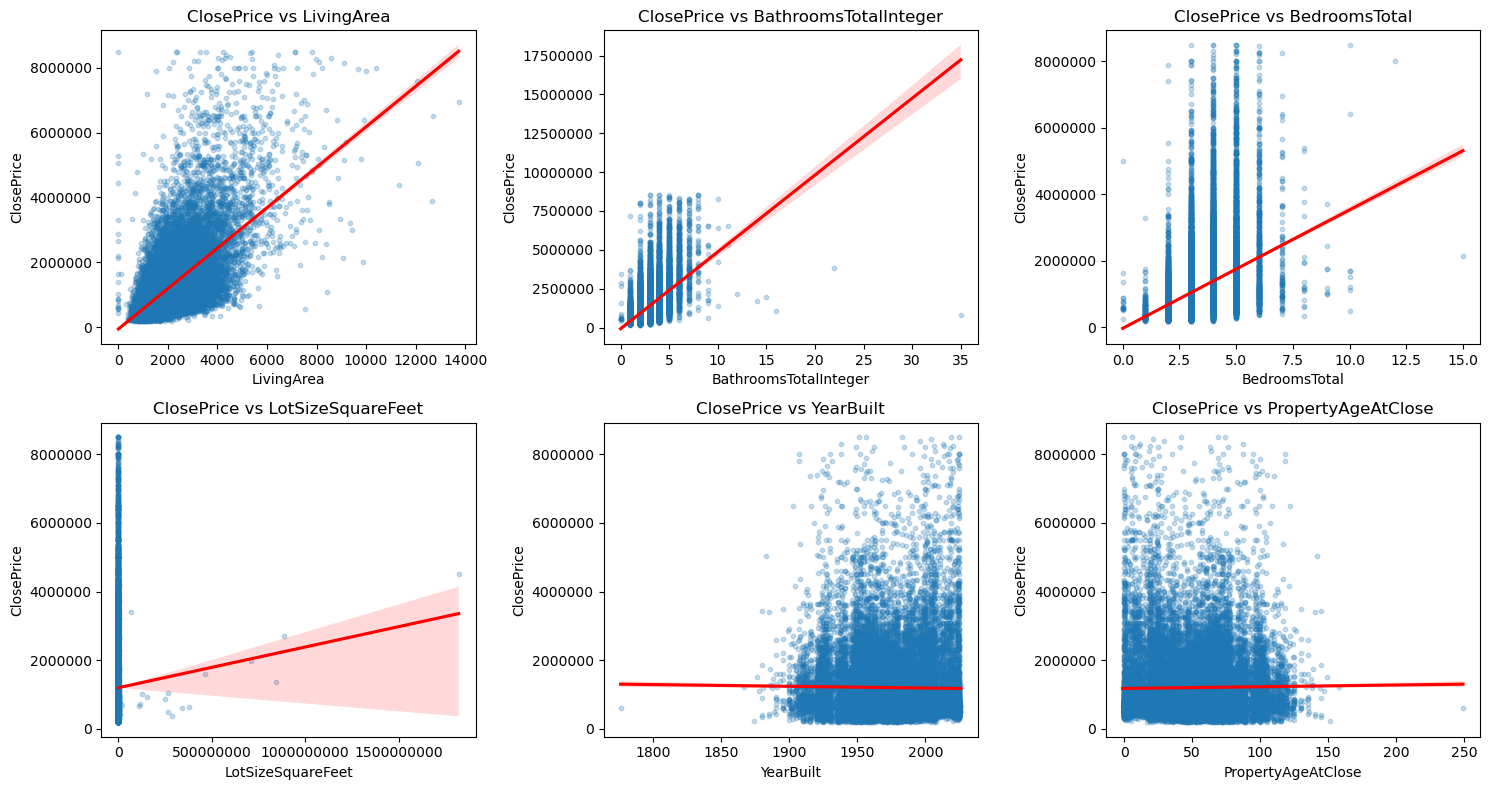

In [20]:
# ClosePrice vs key features (scatter with trendlines)
features_to_plot = [
    'LivingArea',
    'BathroomsTotalInteger',
    'BedroomsTotal',
    'LotSizeSquareFeet',
    'YearBuilt'
]

# Derive property age if dates available
if 'YearBuilt' in combined_dataset.columns and 'CloseDate' in combined_dataset.columns and np.issubdtype(combined_dataset['CloseDate'].dtype, np.datetime64):
    combined_dataset['PropertyAgeAtClose'] = combined_dataset['CloseDate'].dt.year - combined_dataset['YearBuilt']
    features_to_plot.append('PropertyAgeAtClose')

ncols = 3
valid_features = [f for f in features_to_plot if f in combined_dataset.columns]
nrows = int(np.ceil(len(valid_features) / ncols)) or 1
plt.figure(figsize=(5*ncols, 4*nrows))

for i, feat in enumerate(valid_features, 1):
    ax = plt.subplot(nrows, ncols, i)
    dfp = combined_dataset[[feat, 'ClosePrice']].dropna()
    # Sample for speed/readability
    if len(dfp) > 30000:
        dfp = dfp.sample(30000, random_state=42)
    sns.regplot(
        data=dfp,
        x=feat,
        y='ClosePrice',
        scatter_kws={'alpha': 0.25, 's': 10},
        line_kws={'color': 'red'}
    )
    ax.set_title(f'ClosePrice vs {feat}')
    ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()


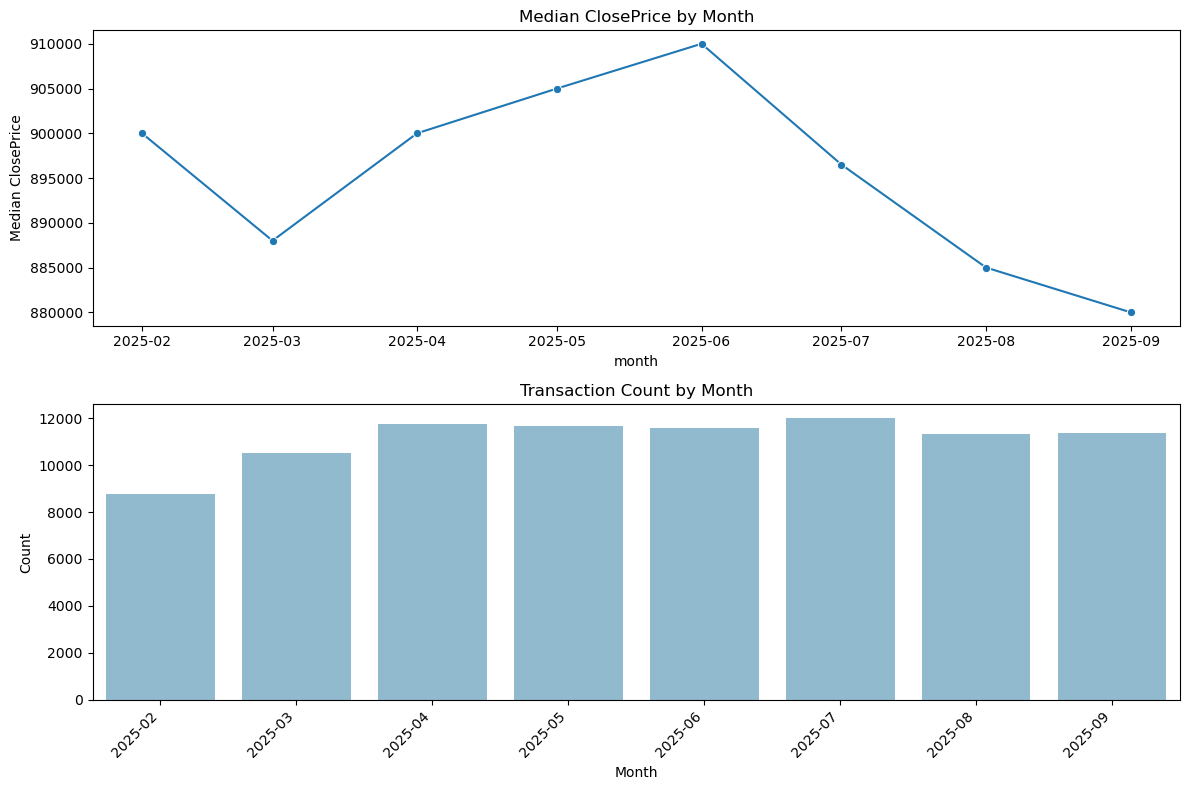

In [21]:
# Monthly ClosePrice trend (median) and volume
if 'CloseDate' in combined_dataset.columns and np.issubdtype(combined_dataset['CloseDate'].dtype, np.datetime64):
    df_time = combined_dataset[['CloseDate', 'ClosePrice']].dropna().copy()
    df_time['month'] = df_time['CloseDate'].dt.to_period('M').dt.to_timestamp()
    monthly = df_time.groupby('month').agg(
        median_price=('ClosePrice', 'median'),
        count=('ClosePrice', 'size')
    ).reset_index()

    # String month label for categorical axis in barplot to avoid datetime unit issues
    monthly['month_str'] = monthly['month'].dt.strftime('%Y-%m')

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
    sns.lineplot(data=monthly, x='month', y='median_price', marker='o', ax=axes[0])
    axes[0].set_title('Median ClosePrice by Month')
    axes[0].set_ylabel('Median ClosePrice')
    axes[0].ticklabel_format(style='plain', axis='y')

    sns.barplot(data=monthly, x='month_str', y='count', ax=axes[1], color='#87bdd8')
    axes[1].set_title('Transaction Count by Month')
    axes[1].set_ylabel('Count')
    axes[1].set_xlabel('Month')
    for label in axes[1].get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

    plt.tight_layout()
    plt.show()
else:
    print('CloseDate not available or not datetime for temporal analysis.')


In [22]:
# Geospatial scatter across California (simple)
if all(col in combined_dataset.columns for col in ['Latitude', 'Longitude', 'ClosePrice']):
    geo = combined_dataset[['Latitude', 'Longitude', 'ClosePrice']].dropna().copy()
    if len(geo) > 20000:
        geo = geo.sample(20000, random_state=42)

    fig_geo = px.scatter_geo(
        geo,
        lat='Latitude',
        lon='Longitude',
        color='ClosePrice',
        color_continuous_scale='Turbo',
        opacity=0.6,
        projection='natural earth',
        title='ClosePrice across California (sampled)'
    )
    fig_geo.update_traces(marker=dict(size=4))
    fig_geo.update_geos(fitbounds="locations", visible=False)
    fig_geo.show()
else:
    print('Latitude/Longitude/ClosePrice not all available for geospatial plot.')


,CountyOrParish,count,median_price
0,Los Angeles,22215,1020000.0
1,Riverside,13688,631750.0
2,San Diego,9813,1055000.0
3,San Bernardino,9477,550000.0
4,Orange,8568,1400000.0
5,Alameda,4390,1302875.0
6,Contra Costa,4299,900000.0
7,Ventura,2895,965000.0
8,Santa Clara,2683,1950000.0
9,San Luis Obispo,1522,935000.0


C:\Users\jueeh\AppData\Local\Temp\ipykernel_34156\2316562879.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




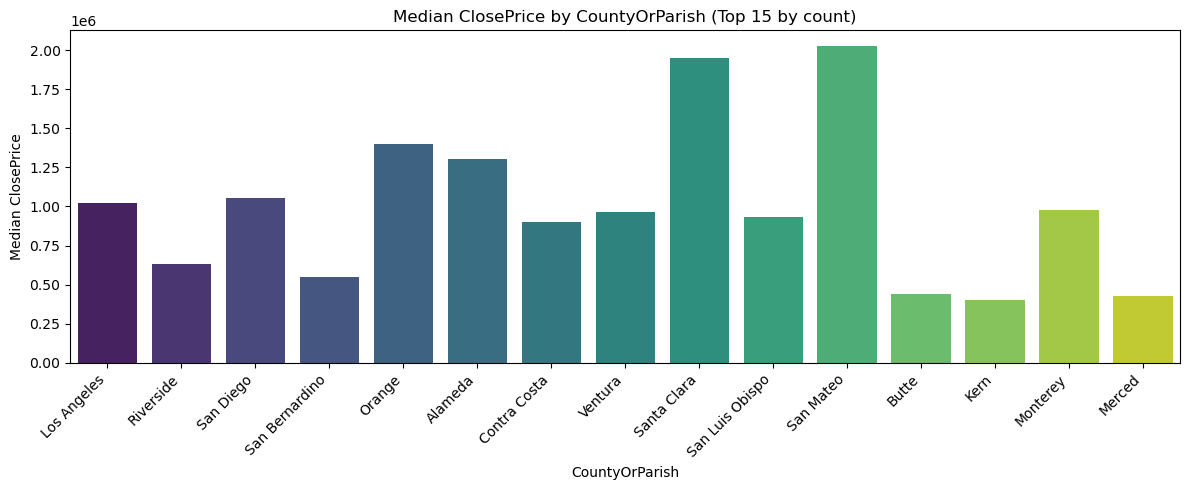

In [23]:
# Show only ONE summary table and ONE chart (first available category)
cat = next((c for c in ['CountyOrParish', 'City', 'PostalCode'] if c in combined_dataset.columns), None)
if cat is None:
    print('No category column found among CountyOrParish/City/PostalCode.')
else:
    grp = (
        combined_dataset[[cat, 'ClosePrice']]
        .dropna(subset=['ClosePrice'])
        .groupby(cat)
        .agg(count=('ClosePrice', 'size'), median_price=('ClosePrice', 'median'))
        .sort_values('count', ascending=False)
        .head(15)
        .reset_index()
    )
    # One dataframe output
    display(grp)

    # One chart output
    plt.figure(figsize=(12, 5))
    sns.barplot(data=grp, x=cat, y='median_price', palette='viridis')
    plt.title(f'Median ClosePrice by {cat} (Top 15 by count)')
    plt.ylabel('Median ClosePrice')
    plt.xlabel(cat)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


,feature,median_true,median_false,median_premium_true_minus_false,mean_true,mean_false,count_true,count_false
0,FireplaceYN,1010000.0,720000.0,290000.0,1.335447e+06,8.572272e+05,64701,24213
1,PoolPrivateYN,1117750.0,830000.0,287750.0,1.505693e+06,1.054129e+06,13950,68135
2,ViewYN,915000.0,865000.0,50000.0,1.260148e+06,1.127888e+06,49271,31443
3,AttachedGarageYN,899000.0,889500.0,9500.0,1.200695e+06,1.178458e+06,65648,12893
4,NewConstructionYN,650000.0,900000.0,-250000.0,1.036414e+06,1.204716e+06,3086,79077


C:\Users\jueeh\AppData\Local\Temp\ipykernel_34156\3864223429.py:43: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




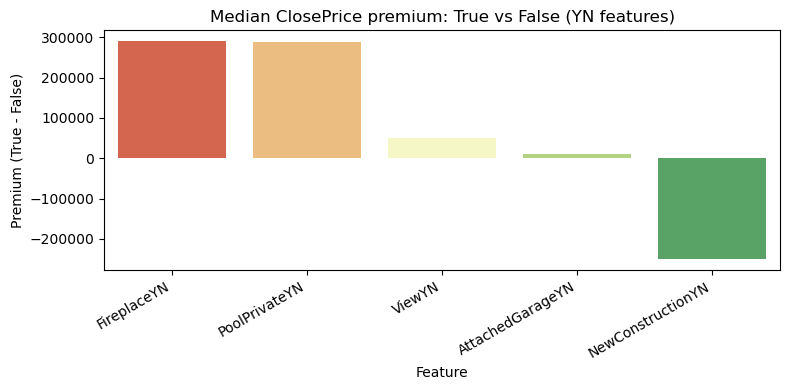

In [24]:
# Relationship of YN features to ClosePrice (simple summary + one chart)
yn_cols = [c for c in ['ViewYN', 'PoolPrivateYN', 'FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN'] if c in combined_dataset.columns]

if not yn_cols:
    print('No YN columns found.')
else:
    df = combined_dataset.copy()

    # Normalize YN columns to booleans (True/False) where possible
    true_vals = {'true', 't', 'y', 'yes', '1', True}
    false_vals = {'false', 'f', 'n', 'no', '0', False}
    for col in yn_cols:
        if df[col].dtype == bool:
            continue
        df[col] = df[col].astype(str).str.strip().str.lower()
        df.loc[df[col].isin(true_vals), col] = True
        df.loc[df[col].isin(false_vals), col] = False
        df[col] = df[col].map({True: True, False: False})  # others become NaN

    # Build summary: median/mean for True vs False and premium (True - False)
    rows = []
    for col in yn_cols:
        grp = df[[col, 'ClosePrice']].dropna(subset=[col, 'ClosePrice']).groupby(col)['ClosePrice'].agg(median='median', mean='mean', count='size')
        med_true = grp.loc[True, 'median'] if True in grp.index else np.nan
        med_false = grp.loc[False, 'median'] if False in grp.index else np.nan
        premium = med_true - med_false if pd.notna(med_true) and pd.notna(med_false) else np.nan
        rows.append({
            'feature': col,
            'median_true': med_true,
            'median_false': med_false,
            'median_premium_true_minus_false': premium,
            'mean_true': grp.loc[True, 'mean'] if True in grp.index else np.nan,
            'mean_false': grp.loc[False, 'mean'] if False in grp.index else np.nan,
            'count_true': int(grp.loc[True, 'count']) if True in grp.index else 0,
            'count_false': int(grp.loc[False, 'count']) if False in grp.index else 0,
        })

    summary_yn = pd.DataFrame(rows).sort_values('median_premium_true_minus_false', ascending=False).reset_index(drop=True)
    display(summary_yn)

    # One compact bar chart: median premium (True - False) by feature
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=summary_yn,
        x='feature',
        y='median_premium_true_minus_false',
        palette='RdYlGn'
    )
    plt.title('Median ClosePrice premium: True vs False (YN features)')
    plt.ylabel('Premium (True - False)')
    plt.xlabel('Feature')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


More Processing of Missing Values

In [25]:
combined_dataset = combined_dataset.drop(columns = ['MainLevelBedrooms'])
if combined_dataset['LivingArea'].isna().mean() < 0.01:
    combined_dataset = combined_dataset.dropna(subset = ['LivingArea'])
else:
    combined_dataset['LivingArea'] = combined_dataset['LivingArea'].fillna(combined_dataset['LivingArea'].mean())

for col in ['BathroomsTotalInteger', 'BedroomsTotal']:
    combined_dataset[col] = combined_dataset[col].fillna(combined_dataset[col].median())


In [26]:
# Normalize, fill, and convert YN columns to bool
yn_cols = ['ViewYN', 'PoolPrivateYN', 'FireplaceYN', 'NewConstructionYN', 'AttachedGarageYN']
yn_cols = [c for c in yn_cols if c in combined_dataset.columns]

true_vals = {'true','t','y','yes','1',True,1}
false_vals = {'false','f','n','no','0',False,0}

for col in yn_cols:
    # normalize to True/False/NA
    s = combined_dataset[col]
    s = s.astype(str).str.strip().str.lower()
    s = np.where(pd.Series(s).isin(true_vals), True,
        np.where(pd.Series(s).isin(false_vals), False, pd.NA))
    combined_dataset[col] = pd.Series(s, index=combined_dataset.index, dtype='boolean')

# Choose ONE fill strategy:
# 1) Conservative: assume missing means False
for col in yn_cols:
    combined_dataset[col] = combined_dataset[col].fillna(False).astype(bool)

# If you prefer majority vote per column instead, replace the loop above with:
# for col in yn_cols:
#     mode_val = combined_dataset[col].mode(dropna=True)
#     fill_val = bool(mode_val.iloc[0]) if len(mode_val) else False
#     combined_dataset[col] = combined_dataset[col].fillna(fill_val).astype(bool)

# Quick check
for col in yn_cols:
    print(col, combined_dataset[col].dtype, combined_dataset[col].isna().sum(), combined_dataset[col].value_counts())

ViewYN bool 0 ViewYN
True     49237
False    39688
Name: count, dtype: int64
PoolPrivateYN bool 0 PoolPrivateYN
False    74977
True     13948
Name: count, dtype: int64
FireplaceYN bool 0 FireplaceYN
True     64672
False    24253
Name: count, dtype: int64
NewConstructionYN bool 0 NewConstructionYN
False    85841
True      3084
Name: count, dtype: int64
AttachedGarageYN bool 0 AttachedGarageYN
True     65642
False    23283
Name: count, dtype: int64


In [27]:
combined_dataset = combined_dataset.drop(columns = ['LotSizeAcres', 'LotSizeSquareFeet', 'LotSizeArea'])

In [28]:
#PropertyAgeAtClose- Dates
#City- Location
#YearBuilt: Date

combined_dataset[(combined_dataset['PropertyAgeAtClose'].isna()) | (combined_dataset['YearBuilt'].isna())][['PropertyAgeAtClose', 'YearBuilt']] #All values where year is missing, PropertyAgeAtClose is misisng too. 
combined_dataset['YearBuilt'] = combined_dataset['YearBuilt'].fillna(combined_dataset['YearBuilt'].median())
combined_dataset['PropertyAgeAtClose'] = combined_dataset['CloseDate'].dt.year - combined_dataset['YearBuilt']


In [29]:
combined_dataset[combined_dataset['City'].isna()][['City', 'CountyOrParish', 'Latitude', 'Longitude']]
combined_dataset['City'] = combined_dataset['City'].fillna(combined_dataset['CountyOrParish'])
combined_dataset

,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,AttachedGarageYN,ParkingTotal,...,BedroomsTotal,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,FireplaceYN,Stories,NewConstructionYN,GarageSpaces,PostalCode,PropertyAgeAtClose
2,False,False,2025-02-11,875000.0,32.765380,-117.043486,2340.0,San Diego,True,6.0,...,4.0,2025-02-11,2021-01-25,2021-01-05,False,1.0,False,2.0,91942,4.0
3,False,False,2025-02-14,875000.0,32.765038,-117.043568,2165.0,San Diego,True,4.0,...,5.0,2025-02-14,2021-01-14,2021-01-05,False,1.0,False,2.0,91942,4.0
4,False,False,2025-02-18,849000.0,32.765031,-117.043252,2158.0,San Diego,True,4.0,...,4.0,2025-02-18,2021-01-25,2020-10-22,False,1.0,False,2.0,91942,4.0
15,True,False,2025-02-28,1100000.0,33.724000,-118.294924,2545.0,Los Angeles,False,3.0,...,4.0,2025-02-28,2025-01-10,2024-11-18,True,2.0,False,2.0,90731,63.0
16,False,False,2025-02-28,760000.0,37.687556,-122.150114,1692.0,Alameda,True,2.0,...,4.0,2025-02-28,2025-02-28,2025-02-28,True,1.0,False,2.0,94579,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178477,True,False,2025-09-03,1530963.0,33.178102,-117.121303,3860.0,San Diego,True,2.0,...,5.0,2025-09-03,2024-04-27,2023-10-06,True,2.0,True,2.0,92026,0.0
178478,True,False,2025-09-15,1032000.0,35.130940,-120.619089,2660.0,San Luis Obispo,True,2.0,...,4.0,2025-09-15,2025-08-16,2023-10-06,True,1.0,False,2.0,93433,27.0
178483,True,False,2025-09-03,1564380.0,33.179057,-117.121584,4049.0,San Diego,True,2.0,...,5.0,2025-09-03,2024-02-26,2023-11-18,False,2.0,True,2.0,92026,0.0
178494,True,True,2025-09-24,669000.0,34.474862,-117.221960,3184.0,San Bernardino,True,8.0,...,4.0,2025-09-24,2025-08-11,2023-02-17,True,1.0,False,4.0,92308,19.0


In [30]:
combined_dataset['ParkingTotal'] = combined_dataset['ParkingTotal'].fillna(0)
combined_dataset[combined_dataset['Latitude'].isna() | combined_dataset['Longitude'].isna()][['Latitude', 'Longitude', 'PostalCode']]

,Latitude,Longitude,PostalCode
15118,NaN,NaN,95337
28162,NaN,NaN,95337
51898,NaN,NaN,95337
106690,NaN,NaN,93921
125256,NaN,NaN,93923


In [31]:
# Fill missing Latitude/Longitude with mean of PostalCode (vectorized)
if all(col in combined_dataset.columns for col in ['Latitude', 'Longitude', 'PostalCode']):
    # Compute mean lat/long per postal code
    postal_means = (
        combined_dataset[['PostalCode', 'Latitude', 'Longitude']]
        .dropna(subset=['PostalCode'])
        .groupby('PostalCode')
        .agg(mean_lat=('Latitude', 'mean'), mean_lon=('Longitude', 'mean'))
    )
    
    # Fill missing values using map (vectorized)
    combined_dataset['Latitude'] = combined_dataset['Latitude'].fillna(
        combined_dataset['PostalCode'].map(postal_means['mean_lat'])
    )
    combined_dataset['Longitude'] = combined_dataset['Longitude'].fillna(
        combined_dataset['PostalCode'].map(postal_means['mean_lon'])
    )
    
    print(f"Missing Latitude after fill: {combined_dataset['Latitude'].isna().sum()}")
    print(f"Missing Longitude after fill: {combined_dataset['Longitude'].isna().sum()}")
else:
    print('Latitude, Longitude, or PostalCode columns not found.')

Missing Latitude after fill: 0
Missing Longitude after fill: 0


In [32]:
combined_dataset = combined_dataset.dropna() #FINAL DATASET: (88920 rows, 23 columns)

Cleaning the October Dataset- Test Set

In [33]:
october = pd.read_csv('original_datasets/CRMLSSold202510.csv')
october

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,NorthSanLuisObispo,NorthSanLuisObispo,NaN,NaN,NaN,NaN,NaN,NaN,479293596,newlin@pacificaCRE.com,...,NaN,1807.00,NaN,NaN,NaN,NaN,93446,NaN,1807.0,NaN
1,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,12000.0,446914808,nleimers@hotmail.com,...,NaN,14253.00,NaN,False,NaN,NaN,92325,0.0,14253.0,NaN
2,SanDiego,SanDiego,Wood,True,NaN,NaN,False,1695.0,445176588,mannybehar@yahoo.com,...,NaN,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23228,SierraNorthValley,SierraNorthValley,NaN,NaN,NaN,NaN,NaN,2988.9,1031966319,mike@cbcnorcal.com,...,NaN,1.98,NaN,NaN,NaN,NaN,95973,NaN,86248.8,NaN
23229,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,49950.0,1024124635,homes@nemechek.com,...,NaN,3784.00,NaN,NaN,NaN,Other,95033,32.0,3784.0,NaN
23230,Southland,Southland,NaN,True,NaN,NaN,NaN,27500.0,1019938353,karmen@bigvalleyrealestate.com,...,NaN,9.79,NaN,False,NaN,NaN,93535,0.0,426452.4,NaN
23231,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,True,NaN,NaN,NaN,405000.0,1016333779,cavanaughcustompropertybrokers@gmail.com,...,NaN,4.34,NaN,NaN,NaN,NaN,92084,0.0,189050.4,NaN


In [34]:
def clean_real_estate_data(df):
    """
    Clean real estate dataset to match the cleaned combined_dataset structure.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Raw real estate dataset
        
    Returns:
    --------
    pd.DataFrame
        Cleaned dataset with 23 columns
    """
    df = df.copy()
    
    # Step 1: Drop columns with >75% missing values
    threshold = 0.75
    cols_to_drop = df.columns[df.isna().mean() > threshold].tolist()
    df = df.drop(columns=cols_to_drop)
    
    # Step 2: Filter for CA, Residential, SingleFamilyResidence
    if 'StateOrProvince' in df.columns:
        df = df[df['StateOrProvince'] == 'CA']
    if 'PropertyType' in df.columns:
        df = df[df['PropertyType'] == 'Residential']
    if 'PropertySubType' in df.columns:
        df = df[df['PropertySubType'] == 'SingleFamilyResidence']
    
    # Step 3: Drop zero variance columns (after filtering)
    zero_variance_cols = df.columns[df.nunique() <= 1].tolist()
    df = df.drop(columns=zero_variance_cols)
    
    # Step 4: Drop specific columns (agent info, listing info, etc.)
    more_columns_to_drop = [
        'ListingKey', 'ListingKeyNumeric', 'ListingId', 'UnparsedAddress', 
        'ListPrice', 'OriginalListPrice', 'DaysOnMarket', 'AssociationFee', 
        'AssociationFeeFrequency', 'HighSchoolDistrict', 'BuyerAgentAOR', 
        'ListAgentAOR', 'BuyerOfficeAOR', 'ListAgentEmail', 'ListAgentFirstName', 
        'ListAgentLastName', 'ListAgentFullName', 'BuyerAgentFirstName', 
        'BuyerAgentLastName', 'BuyerAgentMlsId', 'ListOfficeName', 
        'BuyerOfficeName', 'SubdivisionName', 'Levels', 'Flooring', 
        'MLSAreaMajor', 'StreetNumberNumeric', 'MainLevelBedrooms'
    ]
    cols_to_drop = [c for c in more_columns_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    
    # Step 5: Trim ClosePrice outliers (top and bottom 0.5%)
    if 'ClosePrice' in df.columns:
        close_price_bottom = df['ClosePrice'].quantile(0.005)
        close_price_top = df['ClosePrice'].quantile(0.995)
        df = df[(df['ClosePrice'] >= close_price_bottom) & (df['ClosePrice'] <= close_price_top)]
        df = df.dropna(subset=['ClosePrice'])  # Remove any remaining ClosePrice NaN
    
    # Step 6: Convert date columns to datetime
    date_columns = ['PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate', 'CloseDate']
    date_columns = [c for c in date_columns if c in df.columns]
    for col in date_columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Step 7: Fill Stories with 1 (default for single story)
    if 'Stories' in df.columns:
        df['Stories'] = df['Stories'].fillna(1)
    
    # Step 8: Fill GarageSpaces with ParkingTotal if missing
    if 'GarageSpaces' in df.columns and 'ParkingTotal' in df.columns:
        df.loc[df['GarageSpaces'].isna(), 'GarageSpaces'] = df.loc[df['GarageSpaces'].isna(), 'ParkingTotal']
    
    # Step 9: Handle LivingArea - drop if <1% missing, else fill with mean
    if 'LivingArea' in df.columns:
        if df['LivingArea'].isna().mean() < 0.01:
            df = df.dropna(subset=['LivingArea'])
        else:
            df['LivingArea'] = df['LivingArea'].fillna(df['LivingArea'].mean())
    
    # Step 10: Fill YearBuilt with median, then calculate PropertyAgeAtClose
    if 'YearBuilt' in df.columns and 'CloseDate' in df.columns:
        df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())
        if df['CloseDate'].dtype == 'datetime64[ns]':
            df['PropertyAgeAtClose'] = df['CloseDate'].dt.year - df['YearBuilt']
    
    # Step 11: Fill City with CountyOrParish if missing
    if 'City' in df.columns and 'CountyOrParish' in df.columns:
        df['City'] = df['City'].fillna(df['CountyOrParish'])
    
    # Step 12: Fill ParkingTotal with 0
    if 'ParkingTotal' in df.columns:
        df['ParkingTotal'] = df['ParkingTotal'].fillna(0)
    
    # Step 13: Fill Latitude/Longitude with mean of PostalCode
    if all(col in df.columns for col in ['Latitude', 'Longitude', 'PostalCode']):
        postal_means = (
            df[['PostalCode', 'Latitude', 'Longitude']]
            .dropna(subset=['PostalCode'])
            .groupby('PostalCode')
            .agg(mean_lat=('Latitude', 'mean'), mean_lon=('Longitude', 'mean'))
        )
        df['Latitude'] = df['Latitude'].fillna(
            df['PostalCode'].map(postal_means['mean_lat'])
        )
        df['Longitude'] = df['Longitude'].fillna(
            df['PostalCode'].map(postal_means['mean_lon'])
        )
    
    # Step 14: Convert boolean YN columns to bool and fill missing with False
    boolean_columns = ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']
    true_vals = {'true', 't', 'y', 'yes', '1'}
    
    for col in boolean_columns:
        if col in df.columns:
            if df[col].dtype == bool:
                # Already boolean, fill NaN with False
                df[col] = df[col].fillna(False)
            else:
                # Convert to boolean: True only for explicit True values, everything else False
                # Handle numeric True/False
                mask_true = (df[col] == True) | (df[col] == 1) | (df[col] == 'True') | (df[col] == 'true')
                # Handle string True values
                if df[col].dtype == object:
                    s = df[col].astype(str).str.strip().str.lower()
                    mask_true = mask_true | s.isin(true_vals)
                # Set: True where mask_true, False for everything else (including NaN)
                df[col] = mask_true.fillna(False).astype(bool)
    
    # Step 15: Fill any remaining numeric columns with median (if very few missing)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isna().sum() > 0 and df[col].isna().mean() < 0.05:  # <5% missing
            df[col] = df[col].fillna(df[col].median())
    
    # Step 16: Drop any remaining rows with NaN (final clean)
    df = df.dropna()
    
    return df

# Test the function
print("Cleaning function created successfully!")
print("\nFunction signature:")
print(clean_real_estate_data.__doc__)


Cleaning function created successfully!

Function signature:

    Clean real estate dataset to match the cleaned combined_dataset structure.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Raw real estate dataset
        
    Returns:
    --------
    pd.DataFrame
        Cleaned dataset with 23 columns
    


In [36]:
combined_dataset.to_csv('final_training.csv', index=False)

In [41]:
october = clean_real_estate_data(october)
october = october.drop(columns = ['CoListOfficeName', 'LotSizeSquareFeet', 'LotSizeArea', 'LotSizeAcres'])

In [43]:
october.to_csv('oct_testing.csv', index=False)

In [40]:
combined_dataset.columns

Index(['ViewYN', 'PoolPrivateYN', 'CloseDate', 'ClosePrice', 'Latitude',
       'Longitude', 'LivingArea', 'CountyOrParish', 'AttachedGarageYN',
       'ParkingTotal', 'YearBuilt', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'FireplaceYN', 'Stories', 'NewConstructionYN',
       'GarageSpaces', 'PostalCode', 'PropertyAgeAtClose'],
      dtype='object')